# Derivations & Solutions — Three Roads to the Same $x(t)$

This notebook derives the closed-form motion of the mass–spring–damper **three independent ways** and
verifies they agree, symbolically and numerically:

1. **Classical** — solve the ODE by hand (characteristic equation → cases → initial conditions).
2. **Laplace transform** — transform to algebra in $s$, solve, invert.
3. **State-space** — the matrix exponential $x(t)=e^{At}x(0)$.

Everything is done with [SymPy](https://www.sympy.org). It is the companion to the interactive
`derivations-solutions.html` page.

Governing equation (Lesson 2), normalized with $\omega_n=\sqrt{k/m}$, $\zeta=c/(2\sqrt{km})$:

$$\ddot x + 2\zeta\omega_n\,\dot x + \omega_n^2 x = \omega_n^2\,x_{ss}.$$

Shorthands used throughout: decay rate $\sigma=\zeta\omega_n$ and damped frequency
$\omega_d=\omega_n\sqrt{1-\zeta^2}$.

In [1]:
import sympy as sp
sp.init_printing()

t, s = sp.symbols('t s', positive=True)
wn   = sp.symbols('omega_n', positive=True)
zeta = sp.symbols('zeta', positive=True)
x0, v0, Xss = sp.symbols('x0 v0 X_ss', real=True)
sigma = zeta*wn                     # decay rate
wd    = wn*sp.sqrt(1 - zeta**2)     # damped natural frequency
print("SymPy", sp.__version__)

SymPy 1.14.0


## Route 1 — Classical

### Homogeneous equation and the characteristic guess
Set $F=0$ and try $x=e^{\lambda t}$; each derivative multiplies by $\lambda$, so the ODE becomes a
polynomial in $\lambda$.

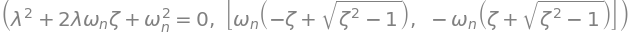

In [2]:
lam = sp.symbols('lambda')
char = sp.Eq(lam**2 + 2*zeta*wn*lam + wn**2, 0)
roots = sp.solve(char, lam)
char, roots

The two roots $\lambda=-\zeta\omega_n\pm\omega_n\sqrt{\zeta^2-1}$ are what the rest of the course
calls the **poles** and (Route 3) the **eigenvalues of $A$**. Their nature depends on $\zeta$:

| damping | $\zeta$ | roots | homogeneous solution |
|---|---|---|---|
| underdamped | $0\le\zeta<1$ | $-\sigma\pm j\omega_d$ | $e^{-\sigma t}(A\cos\omega_d t+B\sin\omega_d t)$ |
| critically damped | $\zeta=1$ | $-\omega_n$ (repeated) | $(A+Bt)\,e^{-\omega_n t}$ |
| overdamped | $\zeta>1$ | $-s_1,-s_2$ (real) | $A e^{-s_1 t}+B e^{-s_2 t}$ |

Let SymPy confirm the general homogeneous solution and each special case.

In [3]:
x = sp.Function('x')
homog = sp.Eq(x(t).diff(t,2) + 2*zeta*wn*x(t).diff(t) + wn**2*x(t), 0)
sp.dsolve(homog, x(t))

In [4]:
# critically damped (zeta = 1): expect (A + B t) e^{-wn t}
sp.dsolve(homog.subs(zeta, 1), x(t))

### Apply the initial conditions (underdamped)
Impose $x(0)=x_0,\ \dot x(0)=v_0$ on $e^{-\sigma t}(A\cos\omega_d t+B\sin\omega_d t)$.

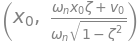

In [5]:
A, B = sp.symbols('A B', real=True)
xh = sp.exp(-sigma*t)*(A*sp.cos(wd*t) + B*sp.sin(wd*t))
A_sol = sp.solve(sp.Eq(xh.subs(t,0), x0), A)[0]
B_sol = sp.solve(sp.Eq(sp.diff(xh,t).subs(t,0).subs(A, A_sol), v0), B)[0]
A_sol, sp.simplify(B_sol)

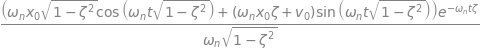

In [6]:
# free response
x_free = xh.subs({A: A_sol, B: B_sol})
x_free = sp.simplify(x_free)
x_free

### Step response (start from rest)
Add the particular solution $x_p=x_{ss}$ and re-apply rest conditions $x(0)=\dot x(0)=0$.

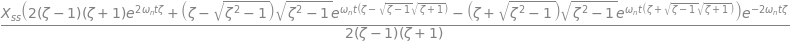

In [7]:
ode_step = sp.Eq(x(t).diff(t,2) + 2*zeta*wn*x(t).diff(t) + wn**2*x(t), wn**2*Xss)
x_step = sp.dsolve(ode_step, x(t), ics={x(0):0, x(t).diff(t).subs(t,0):0}).rhs
sp.simplify(x_step)

## Route 2 — Laplace transform

### The one property that matters
$\mathcal{L}\{\dot x\}=sX(s)-x_0$ and $\mathcal{L}\{\ddot x\}=s^2X(s)-s x_0-v_0$ turn derivatives into
multiplication by $s$, carrying the initial conditions along. Transform the whole free-response equation and
solve for $X(s)$.

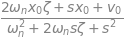

In [8]:
X = sp.symbols('X')   # stands for X(s)
eq_s = sp.Eq((s**2*X - s*x0 - v0) + 2*zeta*wn*(s*X - x0) + wn**2*X, 0)
Xs = sp.solve(eq_s, X)[0]
Xs = sp.simplify(Xs)
Xs   # note the denominator is the characteristic polynomial again

Complete the square in the denominator and invert term by term:

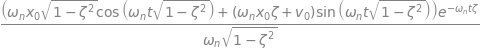

In [9]:
x_lap = sp.inverse_laplace_transform(Xs, s, t)
x_lap = sp.simplify(x_lap)
x_lap

### The step input, via partial fractions

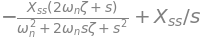

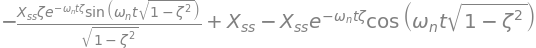

In [10]:
Xstep = wn**2*Xss/(s*(s**2 + 2*zeta*wn*s + wn**2))
display(sp.apart(Xstep, s))
sp.simplify(sp.inverse_laplace_transform(Xstep, s, t))

## Route 3 — State-space

Write $\mathbf{x}=[x,\dot x]^\top$ so $\dot{\mathbf{x}}=A\mathbf{x}$, and solve with the matrix
exponential $\mathbf{x}(t)=e^{At}\mathbf{x}(0)$.

In [11]:
A = sp.Matrix([[0, 1], [-wn**2, -2*zeta*wn]])
A, A.eigenvals()   # eigenvalues are the poles / characteristic roots

⎛⎡ 0       1   ⎤                                                               ↪
⎜⎢             ⎥  ⎧   ⎛       _______   _______⎞        ⎛       _______   ____ ↪
⎜⎢   2         ⎥, ⎨ωₙ⋅⎝-ζ - ╲╱ ζ - 1 ⋅╲╱ ζ + 1 ⎠: 1, ωₙ⋅⎝-ζ + ╲╱ ζ - 1 ⋅╲╱ ζ + ↪
⎝⎣-ωₙ   -2⋅ωₙ⋅ζ⎦  ⎩                                                            ↪

↪         ⎞
↪ ___⎞   ⎫⎟
↪  1 ⎠: 1⎬⎟
↪        ⎭⎠

The full symbolic $e^{At}$ from SymPy is correct but unwieldy; the tidy underdamped form is

$$e^{At}=e^{-\sigma t}\begin{bmatrix}\cos\omega_d t+\frac{\sigma}{\omega_d}\sin\omega_d t & \frac{1}{\omega_d}\sin\omega_d t\\[2pt] -\frac{\omega_n^2}{\omega_d}\sin\omega_d t & \cos\omega_d t-\frac{\sigma}{\omega_d}\sin\omega_d t\end{bmatrix}.$$

We verify that closed form equals SymPy's `A.exp()` numerically, then read off $x(t)$ as its first row times
$[x_0,v_0]^\top$.

d/dt e^{At} - A e^{At} =
⎡0  0⎤
⎢    ⎥
⎣0  0⎦

e^{A*0} =
⎡1  0⎤
⎢    ⎥
⎣0  1⎦


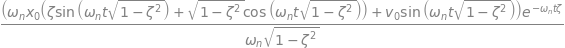

In [12]:
eAt_clean = sp.exp(-sigma*t)*sp.Matrix([
    [sp.cos(wd*t)+sigma/wd*sp.sin(wd*t),           1/wd*sp.sin(wd*t)],
    [-wn**2/wd*sp.sin(wd*t),             sp.cos(wd*t)-sigma/wd*sp.sin(wd*t)]])
# Rigorous check: e^{At} is the unique matrix with  d/dt X = A X  and  X(0) = I.
ode_residual = sp.simplify(sp.diff(eAt_clean, t) - A*eAt_clean)   # must be the zero matrix
at_zero      = sp.simplify(eAt_clean.subs(t, 0))                  # must be the identity
print("d/dt e^{At} - A e^{At} =")
sp.pprint(ode_residual)
print("\ne^{A*0} =")
sp.pprint(at_zero)
x_state = sp.simplify((eAt_clean*sp.Matrix([x0, v0]))[0])
x_state

## Cross-check — do all three agree?

Compare the three closed forms symbolically (difference should simplify to 0) and numerically.

In [13]:
d12 = sp.simplify(x_free - x_lap)
d13 = sp.simplify(x_free - x_state)
print("classical - laplace   simplifies to:", d12)
print("classical - statespace simplifies to:", d13)

classical - laplace   simplifies to: 0
classical - statespace simplifies to: 0


In [14]:
# numeric confirmation, wn=2, zeta=0.3, x0=1, v0=0
import math
subs = {wn:2, zeta:sp.Rational(3,10), x0:1, v0:0}
fc = sp.lambdify(t, x_free.subs(subs), 'math')
fl = sp.lambdify(t, x_lap.subs(subs),  'math')
fs = sp.lambdify(t, x_state.subs(subs),'math')
print(f"{'t':>4} {'classical':>12} {'laplace':>12} {'state-space':>12}")
for tv in [0.0,0.5,1.0,2.0,3.5]:
    print(f"{tv:>4} {fc(tv):>12.6f} {fl(tv):>12.6f} {fs(tv):>12.6f}")

   t    classical      laplace  state-space
 0.0     1.000000     1.000000     1.000000
 0.5     0.618583     0.618583     0.618583
 1.0    -0.018631    -0.018631    -0.018631
 2.0    -0.294431    -0.294431    -0.294431
 3.5     0.127853     0.127853     0.127853


### Plot — three routes, one curve

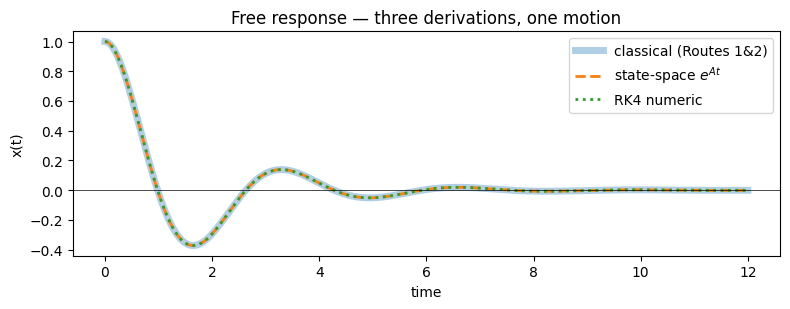

In [15]:
import numpy as np, matplotlib.pyplot as plt
tt = np.linspace(0, 12, 500)
plt.figure(figsize=(8,3.2))
plt.plot(tt, [fc(v) for v in tt], lw=5, alpha=.35, label='classical (Routes 1&2)')
plt.plot(tt, [fs(v) for v in tt], '--', lw=2, label='state-space $e^{At}$')
# independent RK4 of the raw ODE
def rk4(wnv,zv,x0v,v0v,T=12,N=500):
    dt=T/N; s=np.array([x0v,v0v]); out=[s[0]]
    f=lambda st: np.array([st[1], -wnv**2*st[0]-2*zv*wnv*st[1]])
    for _ in range(N):
        k1=f(s);k2=f(s+dt/2*k1);k3=f(s+dt/2*k2);k4=f(s+dt*k3)
        s=s+dt/6*(k1+2*k2+2*k3+k4); out.append(s[0])
    return np.array(out)
plt.plot(np.linspace(0,12,501), rk4(2,0.3,1,0), ':', lw=2, label='RK4 numeric')
plt.axhline(0,color='k',lw=.5); plt.xlabel('time'); plt.ylabel('x(t)')
plt.title('Free response — three derivations, one motion'); plt.legend(); plt.tight_layout(); plt.show()

## Summary

- The **characteristic roots** (classical), the **poles** (Laplace / transfer function), and the
  **eigenvalues of $A$** (state-space) are one and the same set of numbers — the roots of
  $\lambda^2+2\zeta\omega_n\lambda+\omega_n^2=0$.
- All three methods therefore return the **identical** $x(t)$; they differ only in bookkeeping.
- The underdamped free response is
  $$x(t)=e^{-\sigma t}\Big[x_0\cos\omega_d t+\tfrac{v_0+\sigma x_0}{\omega_d}\sin\omega_d t\Big],$$
  and the step response is
  $$x(t)=x_{ss}\Big[1-e^{-\sigma t}\big(\cos\omega_d t+\tfrac{\sigma}{\omega_d}\sin\omega_d t\big)\Big].$$